In [2]:
import glob
import os
from typing import List

import numpy as np
import pandas as pd

from visualization_util import *
import matplotlib.pyplot as plt

COLORS = ["#DD7739", "#3371AD", "#000000"]

COLORS = [color_orange, color_blue, "#101010"]

OUTPUT_DIR_EVALUATION = "_figures"
os.makedirs(OUTPUT_DIR_EVALUATION, exist_ok=True)

In [3]:
n_init = 34
n_rounds = 3
q = 16

In [4]:
def load_results(dir_path):
    file_paths = [os.path.join(dir_path, file) for file in os.listdir(dir_path)]
    file_paths = [file_path for file_path in file_paths if os.path.isfile(file_path)]
    file_paths = sorted(file_paths)
    results_data = []
    identifier = os.path.dirname(dir_path).split(os.sep)[-1].split("_")[0]
    for path in file_paths:
        # basename = os.path.basename(path)
        # name = os.splitext(basename)[0]
        # model_id = int(name.split("_")[-1])
        df = pd.read_csv(path, sep="\t")
        results_data.append(df)

    return results_data, identifier

In [5]:
# result_data = result_data_model
column = "score"


def plot_results(result_data, ax, n_init=34, n_rounds=3, q=16, color="blue", color_lines="#808080",
                 single_trajectories=False, label=None, zorder=None, indicate_rounds=True):
    quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]
    n_points = n_init + n_rounds * q

    X = np.array(range(0, n_points)) + 1

    Y = np.array([[np.max(result_data[iD].iloc[:(iX)][column])
                   for iX in X]
                  for iD in range(0, len(result_data))])

    Y = np.power(2, Y)
    print(Y.shape)
    np.save("Y.npy", Y)
    Y_mean = np.mean(Y, axis=0)
    Y_std = np.std(Y, axis=0)
    Y_quantiles = np.quantile(Y, axis=0, q=quantiles)

    # print(label, np.power(2, Y_mean[-1]), np.power(2, Y_quantiles[:, -1]))
    print(label, Y_mean[-1], Y_quantiles[:, -1])

    Y_max = np.max(Y)

    if single_trajectories:
        for iD in range(Y.shape[0]):
            ax.plot(X, Y[iD], c=color_lines, alpha=0.2)

    ax.plot(X, Y_mean, "-", color=color, label=label, zorder=zorder)
    # ax.plot(X, Y_quantiles[2], color=color, label=label)
    # ax.fill_between(X, Y_quantiles[0], Y_quantiles[-1], color=color, alpha=0.15)
    # ax.fill_between(X, Y_quantiles[1], Y_quantiles[-2], color=color, alpha=0.15)
    # ax.fill_between(X, Y_mean - Y_std, Y_mean + Y_std, alpha=0.2, color=color)

    if indicate_rounds:
        for iR in range(n_rounds + 1):
            ax.plot(np.ones(2) * (n_init + iR * q), np.arange(2) * Y_max * 1.1, "--", color="#808080", zorder=-np.inf)

    #if label is not None:
    #    ax.legend()

    return X, Y_mean



(10, 82)
None 327.58468455800914 [156.3795544  250.5240938  326.10569771 452.45703844 462.5033915 ]


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
        52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
        69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82]),
 array([  1.64260863,   2.02177126,   2.02177126,   3.29226801,
          4.65084749,   5.88092255,   7.20166005,   7.21130822,
          9.99205789,  10.8386115 ,  10.8386115 ,  10.98973081,
         11.28095579,  20.99766584,  21.59460218,  21.59460218,
         21.59460218,  23.02494508,  23.1035188 ,  23.1035188 ,
         23.1035188 ,  23.1035188 ,  23.1035188 ,  23.1035188 ,
         23.1035188 ,  36.08396225,  36.08396225,  36.08396225,
         36.08396225,  36.59990578,  36.59990578,  36.59990578,
         36.59990578,  36.59990578, 129.01610595, 134.22217497,
        161.55115628, 166.27786209, 191.25599542, 191.

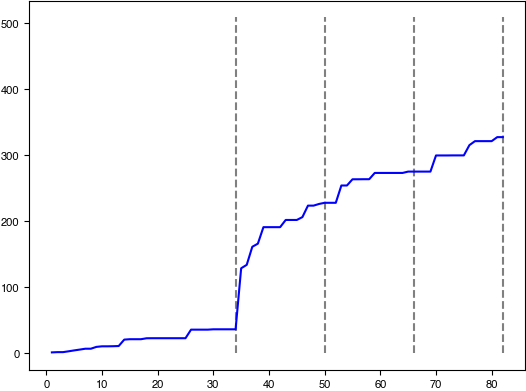

In [6]:
path = "evaluation_results/BO_2026-01-09_10_runs_100/"
result_data_bo, identifier_bo = load_results(path)

fig, ax = plt.subplots()
plot_results(result_data_bo, ax)

(50, 82)
None 268.4300028582113 [156.3795544  156.3795544  221.63271917 370.89947715 462.5033915 ]


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
        52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
        69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82]),
 array([  1.50315571,   2.65464997,   3.45559862,   4.69710582,
          9.41120506,  10.84835334,  11.2690978 ,  11.99966894,
         13.16481056,  16.66135736,  18.41839177,  18.63095664,
         18.70571107,  21.09326665,  23.23555148,  24.85683193,
         24.93855771,  25.08897149,  25.61055689,  25.7271714 ,
         26.5267785 ,  27.19650099,  27.56541873,  27.62672455,
         33.60735647,  33.74962697,  34.36949732,  34.70548264,
         35.20733816,  36.36891697,  36.8957936 ,  37.52995782,
         38.03033278,  41.17612398, 115.94415816, 125.00528514,
        128.44527644, 131.91514823, 132.45736773, 133.

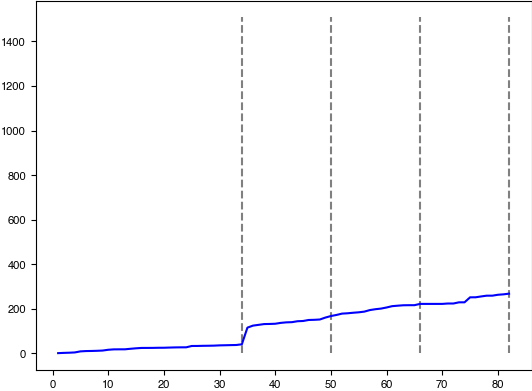

In [7]:
path = "evaluation_results/Model_50_runs_2025-12-17_15-55-47"
result_data_model, identifier_model = load_results(path)

fig, ax = plt.subplots()
plot_results(result_data_model, ax)

(100, 82)
None 75.884728006874 [ 14.01131985  28.9509455   56.4280489   99.45545104 195.08656401]


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
        52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
        69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82]),
 array([ 1.70903176,  7.38927851,  8.14747377,  9.06741287, 10.52915262,
        11.02920192, 13.12809335, 14.57651864, 14.92017312, 16.43786363,
        17.70479529, 18.03000786, 19.00320135, 20.14074486, 24.33855208,
        25.38425396, 26.17555236, 28.13415755, 28.37583486, 31.84674426,
        32.66684638, 33.09120466, 33.38506008, 34.30607177, 36.21778166,
        36.56148973, 36.81429295, 37.91699389, 41.12681234, 41.2924794 ,
        43.26429433, 43.44827704, 44.80566906, 49.05449758, 49.09613641,
        49.48867117, 49.93457236, 49.93457236, 49.95964849, 50.12191657,
        50.12191657, 51.2758326 , 53.59118454,

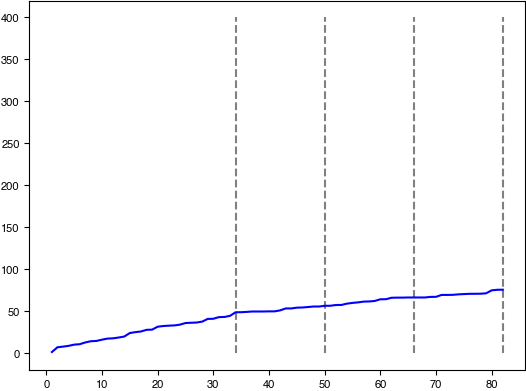

In [8]:
path = "evaluation_results/Random_100_runs_2025-12-05_12-10-18"
result_data_random, identifier_random = load_results(path)

fig, ax = plt.subplots()
plot_results(result_data_random, ax)

(10, 82)
BO 327.58468455800914 [156.3795544  250.5240938  326.10569771 452.45703844 462.5033915 ]
(50, 82)
Model 268.4300028582113 [156.3795544  156.3795544  221.63271917 370.89947715 462.5033915 ]
(100, 82)
Random 75.884728006874 [ 14.01131985  28.9509455   56.4280489   99.45545104 195.08656401]

Performance After Round 0
BO: 36.5999057783998
Model: 41.17612398110463
Random: 49.05449758180115

Performance After Round 1
BO: 228.15120018792126
Model: 168.0045722667596
Random: 56.74069126054532

Performance After Round 2
BO: 275.39462893279057
Model: 222.4419277828414
Random: 66.62850291794547

Performance After Round 3
BO: 327.58468455800914
Model: 268.4300028582113
Random: 75.884728006874


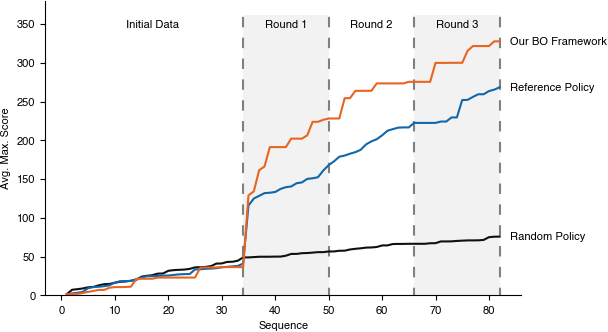

In [13]:
figsize = (160, 90)
fig, ax = plt.subplots(figsize=mm_to_inch(figsize))
X, Y_bo = plot_results(result_data_bo, ax, n_init=n_init, n_rounds=n_rounds, q=q, color=COLORS[0],
                       color_lines="#907070", single_trajectories=False, label="BO", indicate_rounds=False, zorder=2)
X, Y_model = plot_results(result_data_model, ax, n_init=n_init, n_rounds=n_rounds, q=q, color=COLORS[1],
                          color_lines="#7070F0", single_trajectories=False, label="Model", indicate_rounds=False,
                          zorder=1)
X, Y_random = plot_results(result_data_random, ax, n_init=n_init, n_rounds=n_rounds, q=q, color=COLORS[2],
                           color_lines="#806080", label="Random", indicate_rounds=False, zorder=0)

# Y_max = np.max(np.concat([Y_bo, Y_model, Y_random], axis=0))

#Y_max = 10  #Y_max + 2
Y_max = 380

Y_max_indicator = Y_max * 0.95

ax.annotate("Initial Data", xy=(n_init / 2, Y_max * 0.9), xycoords="data", ha="center", va="bottom")
for iR in range(n_rounds + 1):

    ax.plot(np.ones(2) * (n_init + iR * q), np.arange(2) * Y_max_indicator, linestyle=(1.5, (5, 5)), color="#808080",
            zorder=-np.inf)
    ax.annotate(f"Round {iR + 1}", xy=(n_init + iR * q + q / 2, Y_max * 0.9), xycoords="data", ha="center", va="bottom")
    if iR % 2 == 0:
        ax.fill_between(x=(n_init + iR * q, n_init + (iR + 1) * q), y1=(0, 0), y2=(Y_max_indicator, Y_max_indicator),
                        color="#808080", alpha=0.1, linewidth=0, zorder=-np.inf)

    print("")
    print(f"Performance After Round {iR}")
    print(f"BO: {Y_bo[n_init + iR * q - 1]}")
    print(f"Model: {Y_model[n_init + iR * q - 1]}")
    print(f"Random: {Y_random[n_init + iR * q - 1]}")

ax.annotate(f"Our BO Framework", xy=(n_init + n_rounds * q + 2, np.max(Y_bo)), xycoords="data", ha="left",
            va="center")
ax.annotate(f"Reference Policy", xy=(n_init + n_rounds * q + 2, np.max(Y_model)), xycoords="data", ha="left",
            va="center")
ax.annotate(f"Random Policy", xy=(n_init + n_rounds * q + 2, np.max(Y_random)), xycoords="data", ha="left", va="center")

ax.set_ylim(0, Y_max)
ax.set_xlabel("Sequence")
ax.set_ylabel("Avg. Max. Score")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR_EVALUATION, "benchmarking_bayesian_optimization_promoter_dataset.png")

plt.savefig(path, dpi=1200)
# ax.legend()

In [ ]:
n_init